In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score


In [2]:
def train_forest(estimators, depth,X_train_scaled, y_train, X_test_scaled, y_test, class_labels=None):
    # Train Random Forest Classifier
    rf_model = RandomForestClassifier(n_estimators=estimators, max_depth=depth, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = rf_model.predict(X_test_scaled)
    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)), 
                yticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Random Forest (Estimators={estimators}.Depth={depth}) - Confusion Matrix")
    plt.show()

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)

    # Sensitivity (Recall Macro-Averaged)
    sensitivity = recall_score(y_test, y_pred, average='macro')

    # F1 Score Calculation
    f1 = f1_score(y_test, y_pred, average='macro')

    # Specificity Calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Macro Recall): {sensitivity:.4f}")
    print(f"Specificity (Macro Specificity): {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    return rf_model

In [3]:
# Load the robot data
robot_df = pd.read_csv("Classification_of_Robots_from_their_conversation_sequence.csv")

# Separate features and target variable
X = robot_df.iloc[:, 1:]  # Features: num1 to num10
y = robot_df.iloc[:, 0]   # Target: robotID (classification labels)

# Add prefix "Robot" to target labels and encode them
y = y.astype(str).apply(lambda x: f"Robot{x}")  # Prefix "Robot"
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert to numeric labels

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

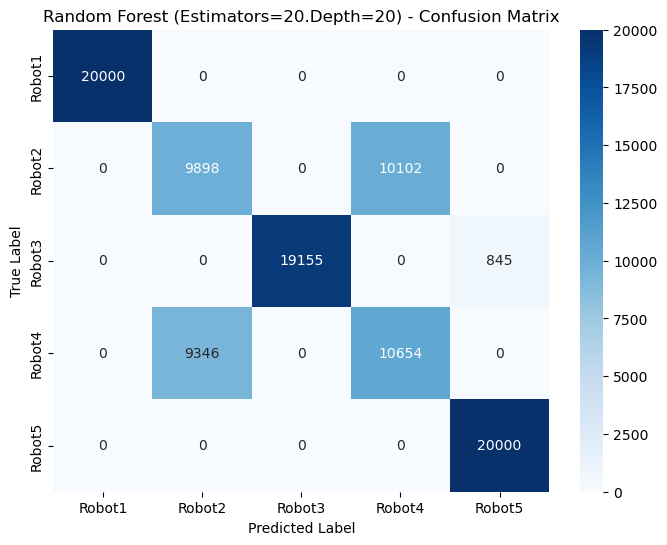

Accuracy: 0.7971
Sensitivity (Macro Recall): 0.7971
Specificity (Macro Specificity): 0.9493
F1 Score: 0.7970

Classification Report:
               precision    recall  f1-score   support

      Robot1       1.00      1.00      1.00     20000
      Robot2       0.51      0.49      0.50     20000
      Robot3       1.00      0.96      0.98     20000
      Robot4       0.51      0.53      0.52     20000
      Robot5       0.96      1.00      0.98     20000

    accuracy                           0.80    100000
   macro avg       0.80      0.80      0.80    100000
weighted avg       0.80      0.80      0.80    100000



In [4]:
rf_model = train_forest(20,20,X_train_scaled,y_train,X_test_scaled,y_test,label_encoder.classes_)

In [5]:
n_estimators_list = [1, 10, 20, 100]
max_depth_list = [1, 5, 10, 20, 100]

results = {}

for n in n_estimators_list:
    for d in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train_scaled, y_train)
        y_pred_rf = rf.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred_rf)
        results[(n, d)] = acc
        print(f"n_estimators={n}, max_depth={d} -> Accuracy: {acc:.4f}")

n_estimators=1, max_depth=1 -> Accuracy: 0.4000
n_estimators=1, max_depth=5 -> Accuracy: 0.7390
n_estimators=1, max_depth=10 -> Accuracy: 0.7705
n_estimators=1, max_depth=20 -> Accuracy: 0.7988
n_estimators=1, max_depth=100 -> Accuracy: 0.8016
n_estimators=10, max_depth=1 -> Accuracy: 0.5999
n_estimators=10, max_depth=5 -> Accuracy: 0.7592
n_estimators=10, max_depth=10 -> Accuracy: 0.7865
n_estimators=10, max_depth=20 -> Accuracy: 0.7968
n_estimators=10, max_depth=100 -> Accuracy: 0.8052
n_estimators=20, max_depth=1 -> Accuracy: 0.6000
n_estimators=20, max_depth=5 -> Accuracy: 0.7608
n_estimators=20, max_depth=10 -> Accuracy: 0.7892
n_estimators=20, max_depth=20 -> Accuracy: 0.7971
n_estimators=20, max_depth=100 -> Accuracy: 0.8065
n_estimators=100, max_depth=1 -> Accuracy: 0.5999
n_estimators=100, max_depth=5 -> Accuracy: 0.7590
n_estimators=100, max_depth=10 -> Accuracy: 0.7893
n_estimators=100, max_depth=20 -> Accuracy: 0.8062
n_estimators=100, max_depth=100 -> Accuracy: 0.8176


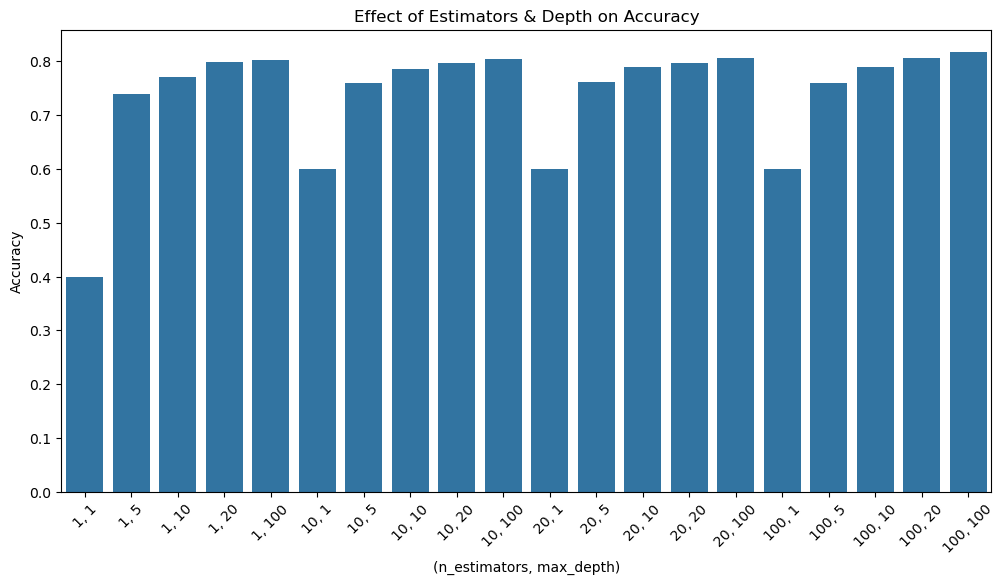

In [6]:
# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results.items(), columns=['Params', 'Accuracy'])

# Split the 'Params' column into 'n_estimators' and 'max_depth'
results_df[['n_estimators', 'max_depth']] = pd.DataFrame(results_df['Params'].tolist(), index=results_df.index)

# Drop the original tuple column
results_df.drop(columns=['Params'], inplace=True)

# Plot Accuracy for different models
plt.figure(figsize=(12,6))
sns.barplot(x=results_df['n_estimators'].astype(str) + ", " + results_df['max_depth'].astype(str), 
            y=results_df['Accuracy'])

plt.xticks(rotation=45)
plt.xlabel("(n_estimators, max_depth)")
plt.ylabel("Accuracy")
plt.title("Effect of Estimators & Depth on Accuracy")
plt.show()


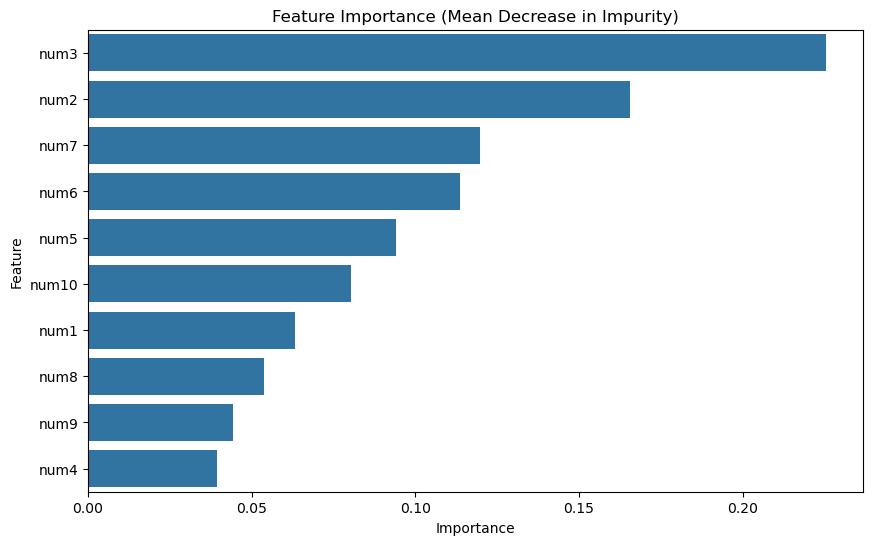

In [7]:
# Feature Importance
feature_importance = rf_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Mean Decrease in Impurity)")
plt.show()